<a href="https://colab.research.google.com/github/mariavasylets/1/blob/master/pr7Vasylets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
data = pd.read_csv("/content/drive/MyDrive/churn_b.csv")
data.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [10]:
data['Churn'].unique()

array([1, 0])

In [11]:
data.dtypes

,0
CustomerID,int64
Age,int64
Gender,object
Tenure,int64
Usage Frequency,int64
Support Calls,int64
Payment Delay,int64
Subscription Type,object
Contract Length,object
Total Spend,int64


In [12]:
data['Churn'].value_counts(normalize=True)

,proportion
Churn,
0,0.526315
1,0.473685


In [14]:
X = data.drop("Churn", axis=1)
Y = pd.get_dummies(data["Churn"], prefix="Churn")

print(X.head())
print(Y.head())

   CustomerID  Age  Gender  Tenure  Usage Frequency  Support Calls  \
0           1   22  Female      25               14              4   
1           2   41  Female      28               28              7   
2           3   47    Male      27               10              2   
3           4   35    Male       9               12              5   
4           5   53  Female      58               24              9   

   Payment Delay Subscription Type Contract Length  Total Spend  \
0             27             Basic         Monthly          598   
1             13          Standard         Monthly          584   
2             29           Premium          Annual          757   
3             17           Premium       Quarterly          232   
4              2          Standard          Annual          533   

   Last Interaction  
0                 9  
1                20  
2                21  
3                18  
4                18  
   Churn_0  Churn_1
0    False     True
1   

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [17]:
to_factor = ["Gender", "Subscription Type", "Contract Length"]
X[to_factor] = X[to_factor].apply(lambda col: pd.factorize(col, sort=True)[0])

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [19]:
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(Dense(32, input_dim=X_train.shape[1], activation="relu"))
model.add(Dense(16, activation="relu"))
model.add(Dense(2, activation="softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [22]:
history = model.fit(X_train, Y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=2)

Epoch 1/50
1288/1288 - 6s - 5ms/step - accuracy: 0.8817 - loss: 0.2663 - val_accuracy: 0.9229 - val_loss: 0.1827
Epoch 2/50
1288/1288 - 3s - 2ms/step - accuracy: 0.9258 - loss: 0.1713 - val_accuracy: 0.9343 - val_loss: 0.1522
Epoch 3/50
1288/1288 - 3s - 2ms/step - accuracy: 0.9394 - loss: 0.1420 - val_accuracy: 0.9436 - val_loss: 0.1313
Epoch 4/50
1288/1288 - 3s - 2ms/step - accuracy: 0.9474 - loss: 0.1237 - val_accuracy: 0.9475 - val_loss: 0.1199
Epoch 5/50
1288/1288 - 3s - 3ms/step - accuracy: 0.9547 - loss: 0.1092 - val_accuracy: 0.9547 - val_loss: 0.1067
Epoch 6/50
1288/1288 - 4s - 3ms/step - accuracy: 0.9605 - loss: 0.0963 - val_accuracy: 0.9621 - val_loss: 0.0963
Epoch 7/50
1288/1288 - 3s - 2ms/step - accuracy: 0.9654 - loss: 0.0874 - val_accuracy: 0.9625 - val_loss: 0.0914
Epoch 8/50
1288/1288 - 3s - 2ms/step - accuracy: 0.9685 - loss: 0.0799 - val_accuracy: 0.9691 - val_loss: 0.0793
Epoch 9/50
1288/1288 - 3s - 2ms/step - accuracy: 0.9709 - loss: 0.0732 - val_accuracy: 0.9725 - 

In [23]:
loss, accuracy = model.evaluate(X_test, Y_test, verbose=0)
print("Test loss:", loss)
print("Test accuracy:", accuracy)

Test loss: 0.028477389365434647
Test accuracy: 0.9897475838661194


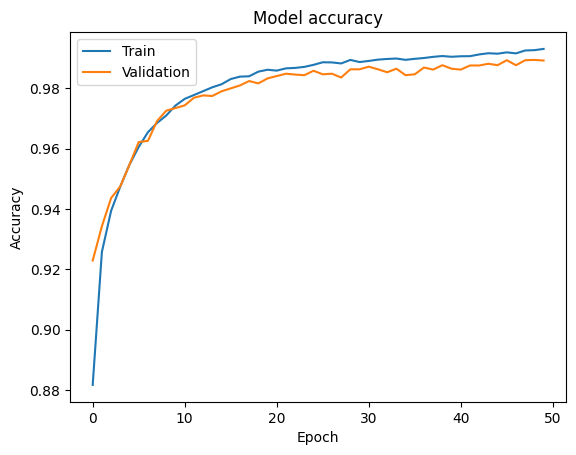

In [24]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'], loc='upper left')
plt.show()

In [26]:
import numpy as np

sample = X_test[0:1]
prediction = model.predict(sample)
score = np.max(prediction)
pred_class = np.argmax(prediction)

print(f"Передбачено клас {pred_class} з достовірністю {score*100:.2f}%")
print(f"Повинно бути: {np.argmax(Y_test[0:1])}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Передбачено клас 0 з достовірністю 100.00%
Повинно бути: 0
